In [1]:
from mnesis_boilerplate import Params, DEBUG, plt, splt, phi, i_pattern, flip_bits, np, printfig
from mnesis_chains import SpikingPattern

datetag = '2026-08-06'
Using device: mps


# generative model for spiking targets: frozen pattern

In [2]:
from mnesis_chains import SpikingPattern

sp = SpikingPattern()
sp.desc

'Frozen Spike pattern generator'

In [3]:
opt = Params()
opt

Params(datetag='2026-08-06', N_neuron=1024, num_delay=41, N_pattern=16, N_time=1000, N_pretime=50, p_A=0.00016, p_flip=0.01, seed=2018, lif_beta=0.8, lif_threshold=0.8, learn_beta=False, learn_threshold=True, do_pinv=True, do_deconv=True, num_epochs=256, num_warmup_epochs=16, base_lr=0.02, final_lr=0.0004, delta1=0.02, delta2=2e-05, dropout=0.1, alpha_surrogate=12.0, surrogate_name='FastSigmoid', loss_name='SpikeF1scoreLoss', reset_mechanism='subtract', optimizer='sgd', verbose=False, fig_width=30, fig_height=15, phi=1.61803, N_time_show=512, N_neuron_show=200, N_scan=36)

In [4]:
sp.init(opt)
sp.frozen_target.shape

torch.Size([16, 1024, 1000])

In [5]:
sp().shape, sp().device

(torch.Size([16, 1024, 1000]), device(type='mps', index=0))

In [6]:
pattern = sp()
pattern.shape, pattern.mean()

(torch.Size([16, 1024, 1000]), tensor(0.000, device='mps:0'))

/Users/laurentperrinet/sdrive_cnrs/hot_from_git/TemporallyHeterogeneousConnections/MNESIS/.venv/lib/python3.12/site-packages/snntorch/spikeplot.py:120: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  return ax.scatter(*torch.where(data.cpu()), **kwargs)


(torch.Size([16, 1024, 1000]), 20.0, 189.0)

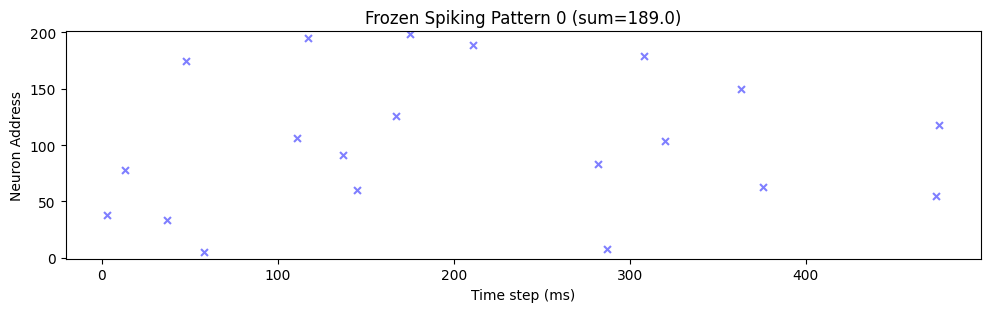

In [7]:
fig, ax = plt.subplots()
splt.raster(pattern[i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, facecolor='blue', edgecolor='none',  marker='x', alpha=.5)
ax.set_xlabel("Time step (ms)")
ax.set_ylabel("Neuron Address")
ax.set_ylim(-1., opt.N_neuron_show + 1.)
ax.set_title(f"Frozen Spiking Pattern {i_pattern} (sum={pattern[i_pattern, :, :].sum().item()})")
printfig(fig, 'frozen', fig_width=opt.fig_width, fig_height=opt.fig_height/2, figpath=None)

pattern.shape, pattern[i_pattern, :opt.N_neuron_show, :opt.N_time_show].sum().item(), pattern[i_pattern, :, :].sum().item()

# generative model for spiking patterns: stochastic pattern

TODO : use a LIF to filter the signal in order to get more realistic spiking patterns

In [8]:
from mnesis_chains import StochasticSpikingPattern

opt = Params()
ssp = StochasticSpikingPattern()
print(f'Description: {ssp.desc}')
ssp.init(opt, verbose=DEBUG)

Description: Stochastic spike pattern generator
Target pattern generated with shape torch.Size([16, 1024, 1000]) and mean 1.605e-04


In [9]:
frozen_target = ssp.frozen_target
frozen_target.shape, frozen_target.min().item(), frozen_target.max().item(), frozen_target.mean().item()


(torch.Size([16, 1024, 1000]), 0.0, 1.0, 0.0001605224679224193)

Showing the target pattern (should not change when calling the generative model):

In [10]:
if DEBUG >1:

    fig, ax = plt.subplots()
    im = ax.imshow(frozen_target[i_pattern, :opt.N_neuron_show, :opt.N_time_show].cpu().T)
    plt.colorbar(im, ax=ax)
    ax.set_xlabel("Time step (ms)")
    ax.set_ylabel("Neuron Address")
    ax.set_ylim(-1., opt.N_neuron_show + 1.)
    printfig(fig, 'ssp_frozen_pattern', fig_width=opt.fig_width, fig_height=opt.fig_height, figpath=None)
    frozen_target.shape, frozen_target[i_pattern, :opt.N_neuron_show, :opt.N_time_show].sum().item(), frozen_target[i_pattern, :, :].sum().item()

In [11]:
ssp.opt.p_flip

0.01

Draw two instances of a pattern:

In [12]:
if DEBUG >1:
    # verification that out frequency is kept constant while the pattern is stochastically modified
    for p_flip in np.linspace(0.0, 1.0, 13):
        print(f'{p_flip=:2e}', end=' - ')
        opt = Params(p_flip=p_flip)
        ssp = StochasticSpikingPattern()
        ssp.init(opt, verbose=False)
        print(f'p_flip={p_flip:.2e} (={ssp.opt.p_flip:.2e}) - Spike count: {ssp.frozen_target.sum().item():.2f} spikes, mean={ssp.frozen_target.mean().item():.3e}')


Target pattern generated with shape torch.Size([16, 1024, 1000]) and mean 1.605e-04
Flipping 1639564.0 bits out of 16384000 (p_flip=0.1, flip seed=6768054680997747589), 1.605e-04 -> 1.002e-01
Flipping 1637485.0 bits out of 16384000 (p_flip=0.1, flip seed=4462900047544077933), 1.605e-04 -> 1.001e-01


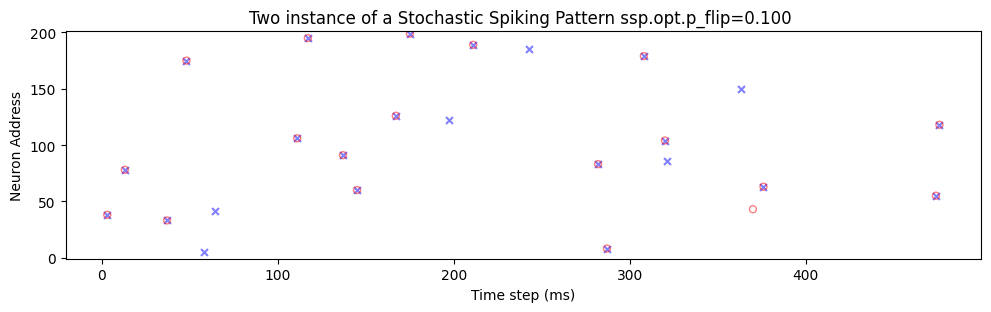

In [13]:
if DEBUG > 0:

    opt = Params(p_flip=.1)
    ssp = StochasticSpikingPattern()
    ssp.init(opt, verbose=DEBUG)

    pattern = ssp(verbose=True)
    pattern2 = ssp(verbose=True)

    fig, ax = plt.subplots()
    splt.raster(pattern[i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, facecolor='blue', edgecolor='none',  marker='x', alpha=.5)
    splt.raster(pattern2[i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, facecolor='none', edgecolor='red',  marker='o', alpha=.5)
    ax.set_xlabel("Time step (ms)")
    ax.set_ylabel("Neuron Address")
    ax.set_ylim(-1., opt.N_neuron_show + 1.)
    ax.set_title(f"Two instance of a Stochastic Spiking Pattern {ssp.opt.p_flip=:.3f} ")
    printfig(fig, 'two_ssp', fig_width=opt.fig_width, fig_height=opt.fig_height/2, figpath=None)
    pattern2.shape, pattern2[i_pattern, :opt.N_neuron_show, :opt.N_time_show].sum().item(), pattern2[i_pattern, :, :].sum().item()